# DS160 Final Project - Stroke Risk Prediction

In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, accuracy_score, confusion_matrix, classification_report

In [75]:
starting_data = pd.read_csv('stroke_risk_dataset.csv')

In [85]:
starting_data.head()

,Chest Pain,Shortness of Breath,Irregular Heartbeat,Fatigue & Weakness,Dizziness,Swelling (Edema),Pain in Neck/Jaw/Shoulder/Back,Excessive Sweating,Persistent Cough,Nausea/Vomiting,High Blood Pressure,Chest Discomfort (Activity),Cold Hands/Feet,Snoring/Sleep Apnea,Anxiety/Feeling of Doom,Age,Stroke Risk (%),At Risk (Binary)
0,0,1,1,1,0,0,0,1,1,1,0,1,1,0,0,54,58.0,1
1,0,0,1,0,0,1,0,0,0,0,1,0,1,1,0,49,40.5,0
2,1,0,0,1,1,1,0,0,1,0,0,0,0,1,0,62,52.0,1
3,1,0,1,1,0,1,1,1,1,1,1,0,0,0,0,48,60.0,1
4,0,0,1,0,0,1,0,1,0,1,1,0,0,1,1,61,56.5,1


In [87]:
symptoms = ['Chest Pain', 'Shortness of Breath', 'Irregular Heartbeat',
                   'Fatigue & Weakness', 'Dizziness', 'Swelling (Edema)',
                   'Pain in Neck/Jaw/Shoulder/Back', 'Excessive Sweating',
                   'Persistent Cough', 'Nausea/Vomiting', 'High Blood Pressure',
                   'Chest Discomfort (Activity)', 'Cold Hands/Feet', 'Snoring/Sleep Apnea',
                   'Anxiety/Feeling of Doom']

data['# of Symptoms'] = data[symptoms].sum(axis=1)

data.head()

,Chest Pain,Shortness of Breath,Irregular Heartbeat,Fatigue & Weakness,Dizziness,Swelling (Edema),Pain in Neck/Jaw/Shoulder/Back,Excessive Sweating,Persistent Cough,Nausea/Vomiting,High Blood Pressure,Chest Discomfort (Activity),Cold Hands/Feet,Snoring/Sleep Apnea,Anxiety/Feeling of Doom,Age,Stroke Risk (%),At Risk (Binary),# of Symptoms
0,0,1,1,1,0,0,0,1,1,1,0,1,1,0,0,54,58.0,1,8
1,0,0,1,0,0,1,0,0,0,0,1,0,1,1,0,49,40.5,0,5
2,1,0,0,1,1,1,0,0,1,0,0,0,0,1,0,62,52.0,1,6
3,1,0,1,1,0,1,1,1,1,1,1,0,0,0,0,48,60.0,1,9
4,0,0,1,0,0,1,0,1,0,1,1,0,0,1,1,61,56.5,1,7


In [89]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 70000 entries, 0 to 69999
Data columns (total 19 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Chest Pain                      70000 non-null  int64  
 1   Shortness of Breath             70000 non-null  int64  
 2   Irregular Heartbeat             70000 non-null  int64  
 3   Fatigue & Weakness              70000 non-null  int64  
 4   Dizziness                       70000 non-null  int64  
 5   Swelling (Edema)                70000 non-null  int64  
 6   Pain in Neck/Jaw/Shoulder/Back  70000 non-null  int64  
 7   Excessive Sweating              70000 non-null  int64  
 8   Persistent Cough                70000 non-null  int64  
 9   Nausea/Vomiting                 70000 non-null  int64  
 10  High Blood Pressure             70000 non-null  int64  
 11  Chest Discomfort (Activity)     70000 non-null  int64  
 12  Cold Hands/Feet                 

In [91]:
data.describe()

,Chest Pain,Shortness of Breath,Irregular Heartbeat,Fatigue & Weakness,Dizziness,Swelling (Edema),Pain in Neck/Jaw/Shoulder/Back,Excessive Sweating,Persistent Cough,Nausea/Vomiting,High Blood Pressure,Chest Discomfort (Activity),Cold Hands/Feet,Snoring/Sleep Apnea,Anxiety/Feeling of Doom,Age,Stroke Risk (%),At Risk (Binary),# of Symptoms
count,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000
mean,0.501871,0.496471,0.498886,0.500100,0.503043,0.500557,0.499186,0.503671,0.500800,0.501943,0.500643,0.499557,0.498871,0.500686,0.499871,54.056429,55.558771,0.649200,7.506157
std,0.500000,0.499991,0.500002,0.500004,0.499994,0.500003,0.500003,0.499990,0.500003,0.500000,0.500003,0.500003,0.500002,0.500003,0.500004,21.071567,14.300898,0.477224,1.943072
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,18.000000,5.000000,0.000000,1.000000
25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,36.000000,45.500000,0.000000,6.000000
50%,1.000000,0.000000,0.000000,1.000000,1.000000,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,1.000000,0.000000,54.000000,55.500000,1.000000,8.000000
75%,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,72.000000,66.000000,1.000000,9.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,90.000000,100.000000,1.000000,15.000000


In [93]:
data.isnull().sum()

Chest Pain                        0
Shortness of Breath               0
Irregular Heartbeat               0
Fatigue & Weakness                0
Dizziness                         0
Swelling (Edema)                  0
Pain in Neck/Jaw/Shoulder/Back    0
Excessive Sweating                0
Persistent Cough                  0
Nausea/Vomiting                   0
High Blood Pressure               0
Chest Discomfort (Activity)       0
Cold Hands/Feet                   0
Snoring/Sleep Apnea               0
Anxiety/Feeling of Doom           0
Age                               0
Stroke Risk (%)                   0
At Risk (Binary)                  0
# of Symptoms                     0
dtype: int64

In [95]:
data.columns

Index(['Chest Pain', 'Shortness of Breath', 'Irregular Heartbeat',
       'Fatigue & Weakness', 'Dizziness', 'Swelling (Edema)',
       'Pain in Neck/Jaw/Shoulder/Back', 'Excessive Sweating',
       'Persistent Cough', 'Nausea/Vomiting', 'High Blood Pressure',
       'Chest Discomfort (Activity)', 'Cold Hands/Feet', 'Snoring/Sleep Apnea',
       'Anxiety/Feeling of Doom', 'Age', 'Stroke Risk (%)', 'At Risk (Binary)',
       '# of Symptoms'],
      dtype='object')

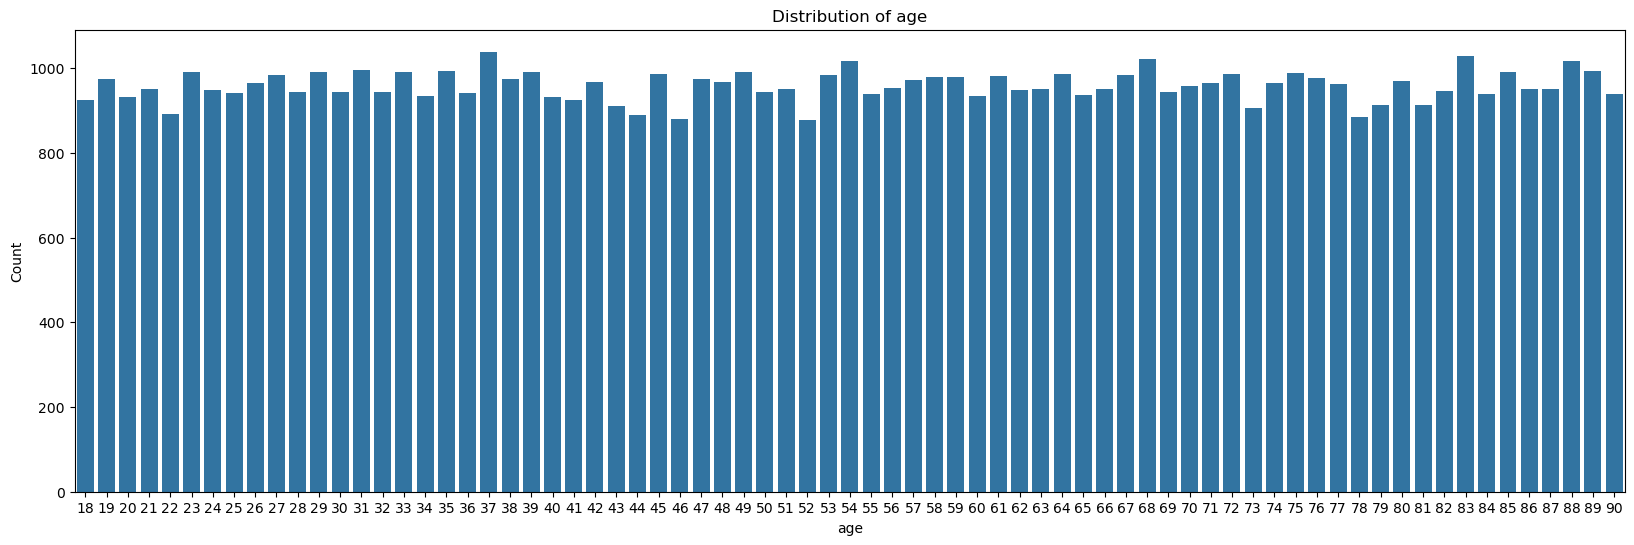

In [97]:
plt.figure(figsize=(20,6))
sns.countplot(x='Age', data=data)
plt.title('Distribution of age')
plt.xlabel('age')
plt.ylabel('Count')
plt.show()

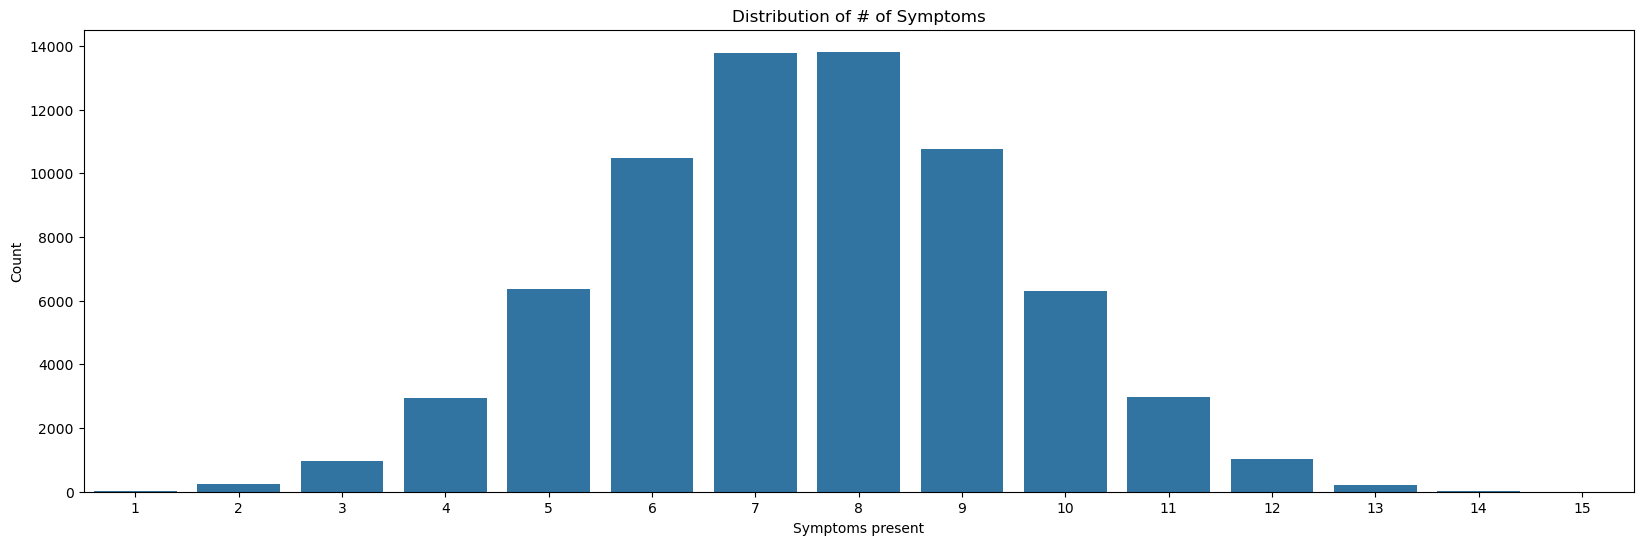

In [167]:
plt.figure(figsize=(20,6))
sns.countplot(x='# of Symptoms', data=data)
plt.title('Distribution of # of Symptoms')
plt.xlabel('Symptoms present')
plt.ylabel('Count')
plt.show()

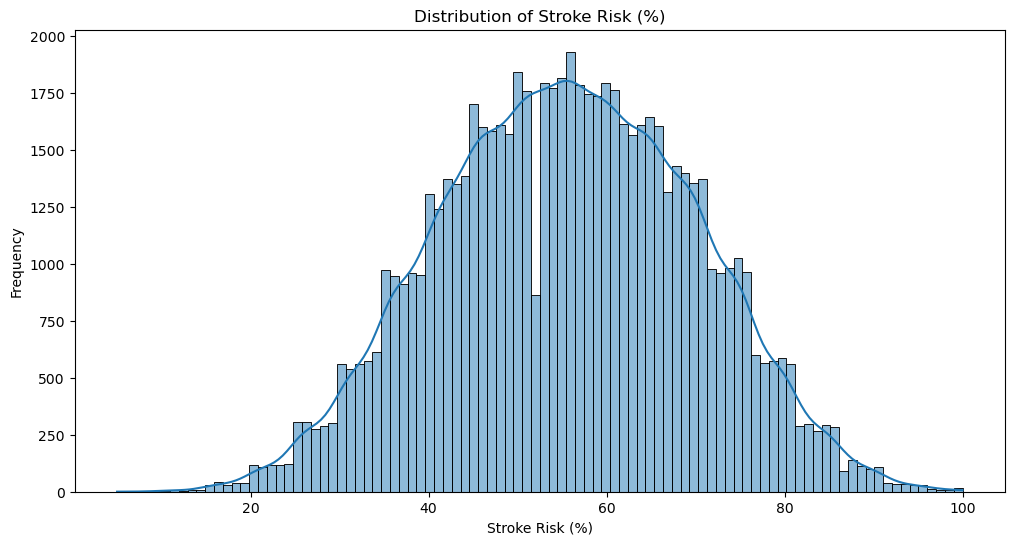

In [33]:
plt.figure(figsize=(12,6))
sns.histplot(data['Stroke Risk (%)'], kde=True)
plt.title('Distribution of Stroke Risk (%)')
plt.xlabel('Stroke Risk (%)')
plt.ylabel('Frequency')
plt.show()

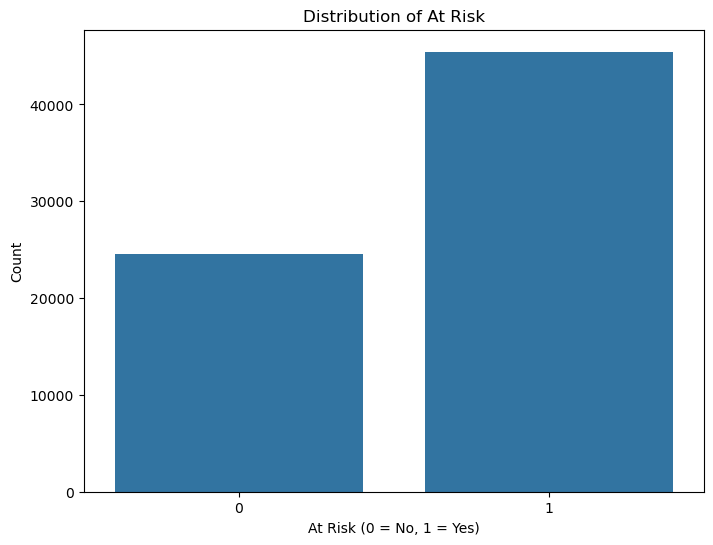

In [35]:
plt.figure(figsize=(8,6))
sns.countplot(x='At Risk (Binary)', data=data)
plt.title('Distribution of At Risk')
plt.xlabel('At Risk (0 = No, 1 = Yes)')
plt.ylabel('Count')
plt.show()

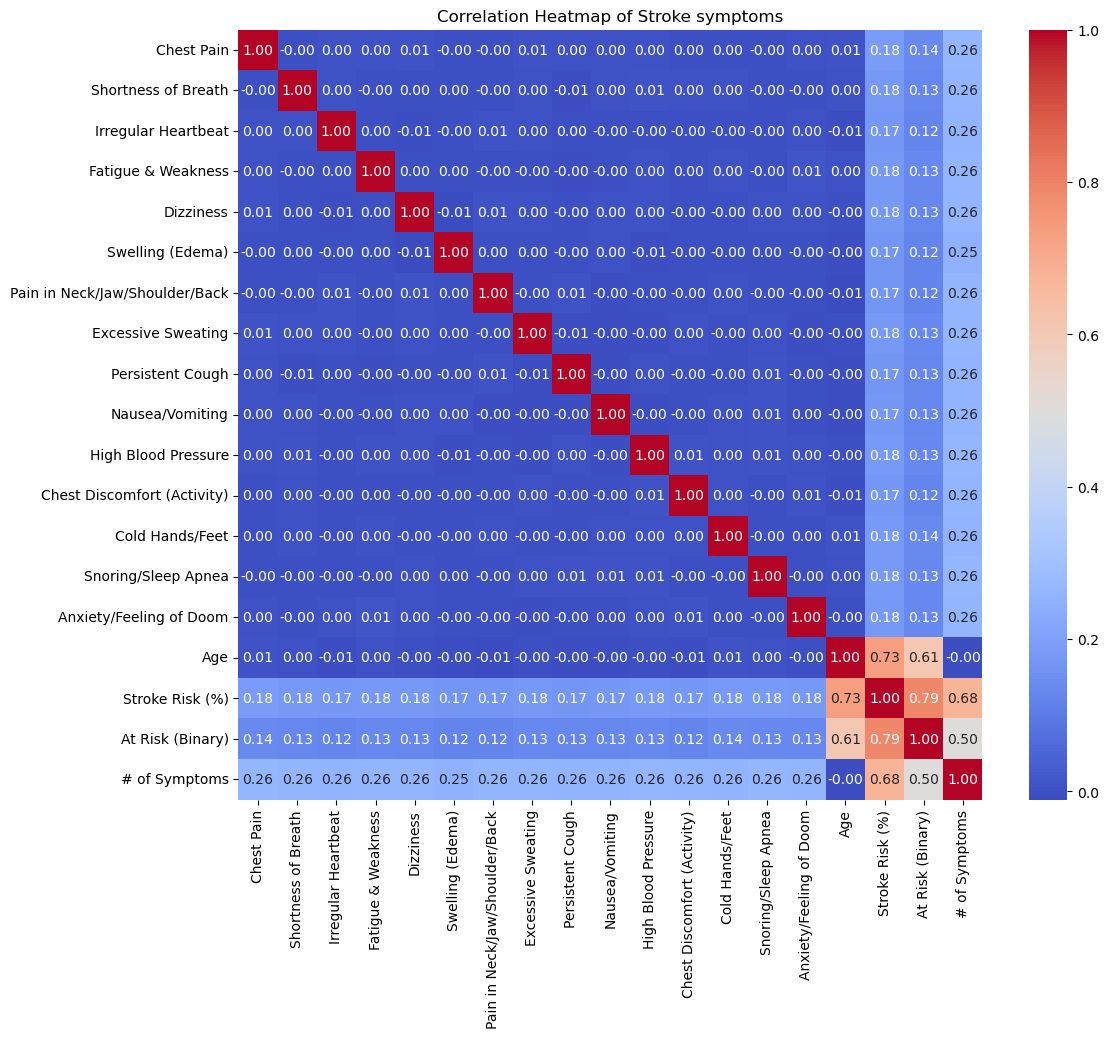

In [99]:
plt.figure(figsize=(12,10))
corr = data.corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation Heatmap of Stroke symptoms')
plt.show()

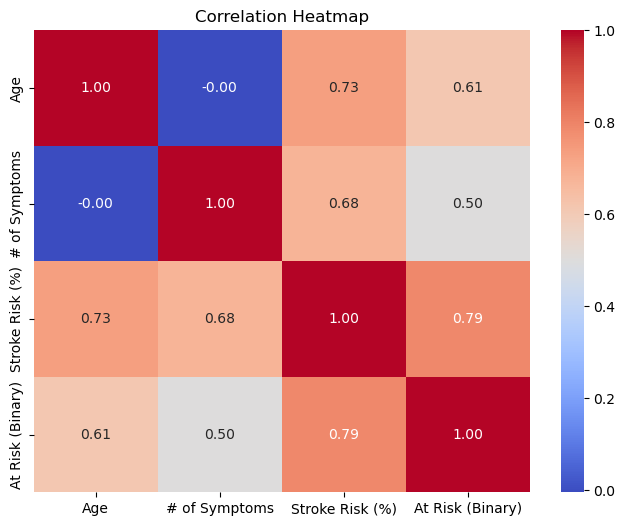

In [111]:
plt.figure(figsize=(8,6))
data_small = data[['Age', '# of Symptoms', 'Stroke Risk (%)', 'At Risk (Binary)']]
corr2 = data_small.corr()
sns.heatmap(corr2, annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

In [197]:
data.columns

Index(['Chest Pain', 'Shortness of Breath', 'Irregular Heartbeat',
       'Fatigue & Weakness', 'Dizziness', 'Swelling (Edema)',
       'Pain in Neck/Jaw/Shoulder/Back', 'Excessive Sweating',
       'Persistent Cough', 'Nausea/Vomiting', 'High Blood Pressure',
       'Chest Discomfort (Activity)', 'Cold Hands/Feet', 'Snoring/Sleep Apnea',
       'Anxiety/Feeling of Doom', 'Age', 'Stroke Risk (%)', 'At Risk (Binary)',
       '# of Symptoms'],
      dtype='object')

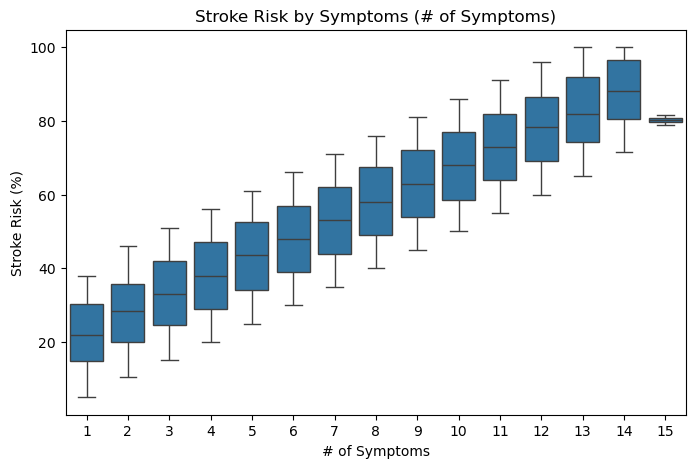

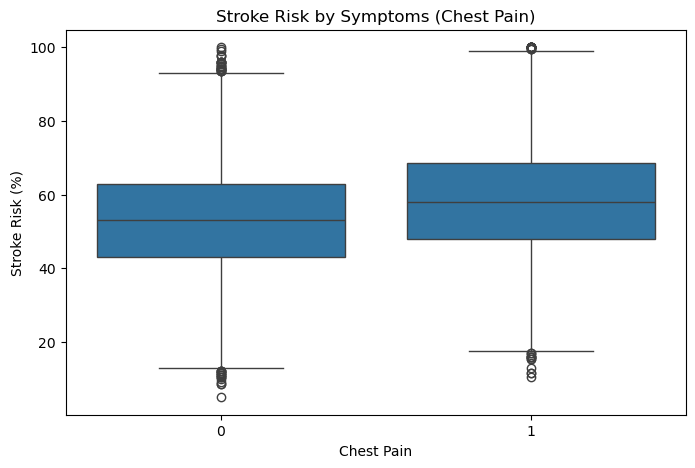

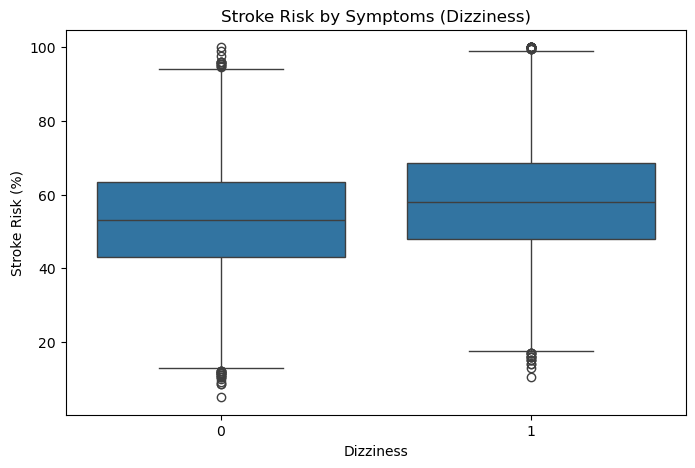

In [199]:
plt.figure(figsize=(8,5))
sns.boxplot(x='# of Symptoms', y='Stroke Risk (%)', data=data)
plt.title('Stroke Risk by Symptoms (# of Symptoms)')
plt.show()

plt.figure(figsize=(8,5))
sns.boxplot(x='Chest Pain', y='Stroke Risk (%)', data=data)
plt.title('Stroke Risk by Symptoms (Chest Pain)')
plt.show()

plt.figure(figsize=(8,5))
sns.boxplot(x='Dizziness', y='Stroke Risk (%)', data=data)
plt.title('Stroke Risk by Symptoms (Dizziness)')
plt.show()

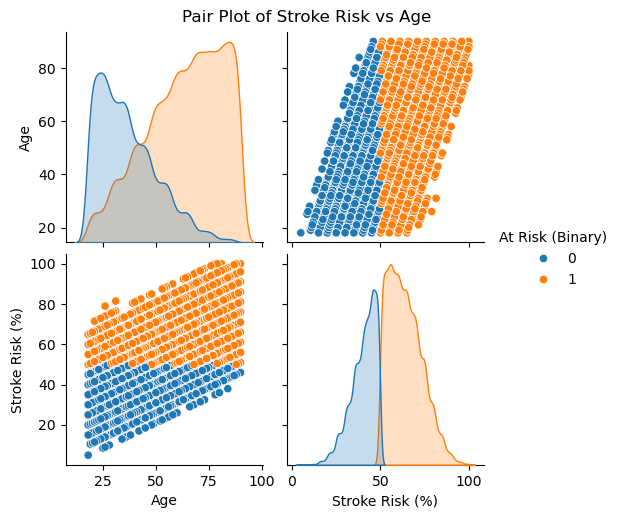

In [201]:
sns.pairplot(data[['Age', 'Stroke Risk (%)',
       'At Risk (Binary)']], hue='At Risk (Binary)')
plt.suptitle('Pair Plot of Stroke Risk vs Age', y=1.02)
plt.show()

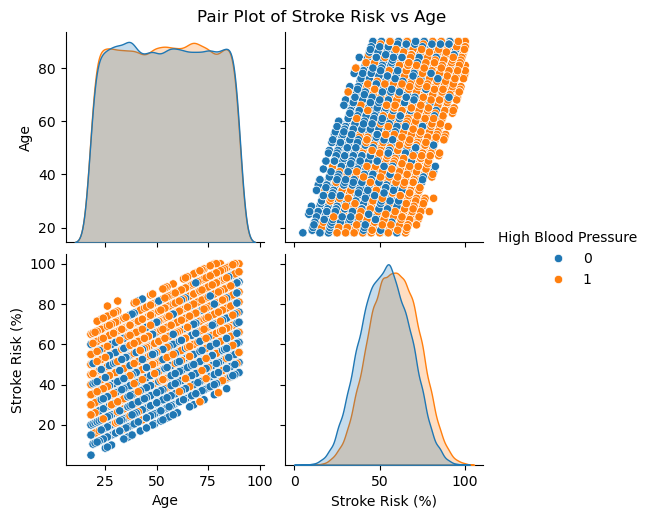

In [204]:
sns.pairplot(data[['Age', 'Stroke Risk (%)',
       'High Blood Pressure']], hue='High Blood Pressure')
plt.suptitle('Pair Plot of Stroke Risk vs Age', y=1.02)
plt.show()

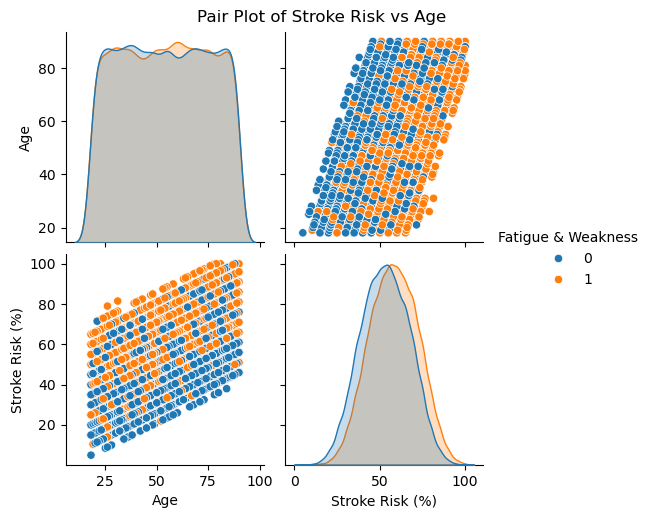

In [208]:
sns.pairplot(data[['Age', 'Stroke Risk (%)',
       'Fatigue & Weakness']], hue='Fatigue & Weakness')
plt.suptitle('Pair Plot of Stroke Risk vs Age', y=1.02)
plt.show()

In [129]:
X = data[['Age', 'Chest Pain', 'Shortness of Breath', 'Irregular Heartbeat',
       'Fatigue & Weakness', 'Dizziness', 'Swelling (Edema)',
       'Pain in Neck/Jaw/Shoulder/Back', 'Excessive Sweating',
       'Persistent Cough', 'Nausea/Vomiting', 'High Blood Pressure',
       'Chest Discomfort (Activity)', 'Cold Hands/Feet', 'Snoring/Sleep Apnea',
       'Anxiety/Feeling of Doom','# of Symptoms']]
y = data['Stroke Risk (%)']

### Model 1

In [131]:
X_train, X_test, y_train, y_test = train_test_split(X, y, 
                                                    test_size=0.2, 
                                                    random_state=0
                                                   )

In [133]:
model = LinearRegression()
model.fit(X_train, y_train) 

y_pred = model.predict(X_test)

In [135]:
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print('Mean squared error', mse)
print('Root mean squared error', rmse)
print('R square', r2)

Mean squared error 7.212163808644858e-05
Root mean squared error 0.008492445942509648
R square 0.9999996485993495


In [137]:
X.sample()

,Age,Chest Pain,Shortness of Breath,Irregular Heartbeat,Fatigue & Weakness,Dizziness,Swelling (Edema),Pain in Neck/Jaw/Shoulder/Back,Excessive Sweating,Persistent Cough,Nausea/Vomiting,High Blood Pressure,Chest Discomfort (Activity),Cold Hands/Feet,Snoring/Sleep Apnea,Anxiety/Feeling of Doom,# of Symptoms
34356,37,0,0,1,1,1,1,0,1,0,1,0,0,1,0,0,7


In [141]:
model.predict([[88,0,0,1,0,1,1,0,1,0,1,1,0,0,1,0,7]])

C:\Users\ellie\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([69.99965702])

In [143]:
model.predict([[65,1,0,1,1,1,0,0,0,0,0,1,1,0,0,1,7]])

C:\Users\ellie\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([58.50022763])

In [139]:
model.predict([[20,1,1,0,1,0,0,1,0,1,0,0,1,1,0,1,8]])

C:\Users\ellie\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([40.99981797])

### Model 2

In [169]:
X_train2, X_test2, y_train2, y_test2 = train_test_split(X, y, 
                                                    test_size=0.3, 
                                                    random_state=0)

In [173]:
model2 = LinearRegression()
model2.fit(X_train2, y_train2) 

y_pred2 = model2.predict(X_test2)

In [175]:
mse2 = mean_squared_error(y_test2, y_pred2)
rmse2 = np.sqrt(mse2)
r22 = r2_score(y_test2, y_pred2)

print('Mean squared error', mse2)
print('Root mean squared error', rmse2)
print('R square', r22)

Mean squared error 4.8791215880574506e-05
Root mean squared error 0.006985070928814861
R square 0.9999997616331122


In [177]:
model2.predict([[88,0,0,1,0,1,1,0,1,0,1,1,0,0,1,0,7]])

C:\Users\ellie\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([69.99959471])

In [179]:
model2.predict([[65,1,0,1,1,1,0,0,0,0,0,1,1,0,0,1,7]])

C:\Users\ellie\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([58.50026493])

In [181]:
model2.predict([[20,1,1,0,1,0,0,1,0,1,0,0,1,1,0,1,8]])

C:\Users\ellie\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([40.99980418])

### Model 3

In [189]:
X_select = data[['Age','Chest Pain','Irregular Heartbeat','Fatigue & Weakness','Dizziness',
          'High Blood Pressure','Chest Discomfort (Activity)','Anxiety/Feeling of Doom']]
y_select = data['Stroke Risk (%)']

X_train3, X_test3, y_train3, y_test3 = train_test_split(X_select, y_select,
                                                    test_size=0.2,
                                                    random_state=0)

model3 = LinearRegression()
model3.fit(X_train3, y_train3)

y_pred3 = model3.predict(X_test3)

mse3 = mean_squared_error(y_test3, y_pred3)
rmse3 = np.sqrt(mse3)
r23 = r2_score(y_test3, y_pred3)

print('Mean squared error', mse3)
print('Root mean squared error', rmse3)
print('R square', r23)

Mean squared error 48.810700807936094
Root mean squared error 6.9864655447469355
R square 0.7621780027634335


### Model 4

In [195]:
X_train4, X_test4, y_train4, y_test4 = train_test_split(X_select, y_select,
                                                    test_size=0.3,
                                                    random_state=0)

model4 = LinearRegression()
model4.fit(X_train4, y_train4)

y_pred4 = model4.predict(X_test4)

mse4 = mean_squared_error(y_test4, y_pred4)
rmse4 = np.sqrt(mse4)
r24 = r2_score(y_test4, y_pred4)

print('Mean squared error', mse4)
print('Root mean squared error', rmse4)
print('R square', r24)

Mean squared error 49.599389343884184
Root mean squared error 7.04268339085921
R square 0.7576848238163447
